In [1]:
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile
import torch
import torch.nn.functional as F
import yaml
from pathlib import Path
from types import SimpleNamespace

plt.rcParams.update({'figure.dpi': 600, 'font.size': 11})

ROOT  = Path('/mnt/intelpa-1/armin/containers/storage/main/research_3')
LOGS  = ROOT / 'logs' / '3dgs'
ABLATION = LOGS / 'ablation'
ABLATION.mkdir(exist_ok=True)

with open(ROOT / 'configs' / '3dgs.yml') as f:
    DEFAULT_CFG = yaml.safe_load(f)

def resolve_path(p):
    p = Path(p)
    return p if p.is_absolute() else ROOT / p


## 1 · Load results

In [2]:
RUN_DIRS = sorted([
    p for p in LOGS.iterdir()
    if p.is_dir() and p.name == 'run' and (p / 'log.json').exists()
])
assert RUN_DIRS, f'No 3DGS runs found under {LOGS}'

records = []
for run_dir in RUN_DIRS:
    run  = run_dir.name
    log  = json.loads((run_dir / 'log.json').read_text())
    cfg  = json.loads((run_dir / 'config.json').read_text()) if (run_dir / 'config.json').exists() else {}
    log_df = pd.DataFrame(log)
    psnr_col = 'vol_psnr' if log_df['vol_psnr'].notna().any() else 'psnr'
    psnr_vals = pd.to_numeric(log_df[psnr_col], errors='coerce')
    best_idx  = int(psnr_vals.idxmax())
    m_path    = run_dir / 'metrics.json'
    m         = json.loads(m_path.read_text()) if m_path.exists() else {}

    records.append({
        'run':             run,
        'n_init':          cfg.get('n_init',          DEFAULT_CFG.get('n_init')),
        'max_gaussians':   cfg.get('max_gaussians',   DEFAULT_CFG.get('max_gaussians')),
        'densify_from':    cfg.get('densify_from_step', DEFAULT_CFG.get('densify_from_step')),
        'densify_until':   cfg.get('densify_until_step', DEFAULT_CFG.get('densify_until_step')),
        'densify_interval':cfg.get('densify_interval', DEFAULT_CFG.get('densify_interval')),
        'epochs_trained':  int(log_df.iloc[-1]['epoch']),
        'steps_trained':   int(log_df.iloc[-1]['step']),
        'train_min':       round(log_df.iloc[-1]['elapsed_s'] / 60, 1),
        'best_psnr':       round(float(psnr_vals.iloc[best_idx]), 4),
        'final_n_gauss':   int(log_df.iloc[-1]['n_gauss']),
        'best_epoch':      int(log_df.iloc[best_idx]['epoch']),
        'ssim':            m.get('ssim'),
        'lpips':           m.get('lpips'),
    })

df = pd.DataFrame(records)
print(df[['run','n_init','max_gaussians','epochs_trained','best_psnr','final_n_gauss','train_min']].to_string(index=False))


run  n_init  max_gaussians  epochs_trained  best_psnr  final_n_gauss  train_min
run   10000          50000            1000     42.181          50000       54.6


## 2 · Load training curves

/tmp/ipykernel_3980494/1152736375.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_dir / 'best_20260501.pth')


torch.Size([113, 1024, 1024])


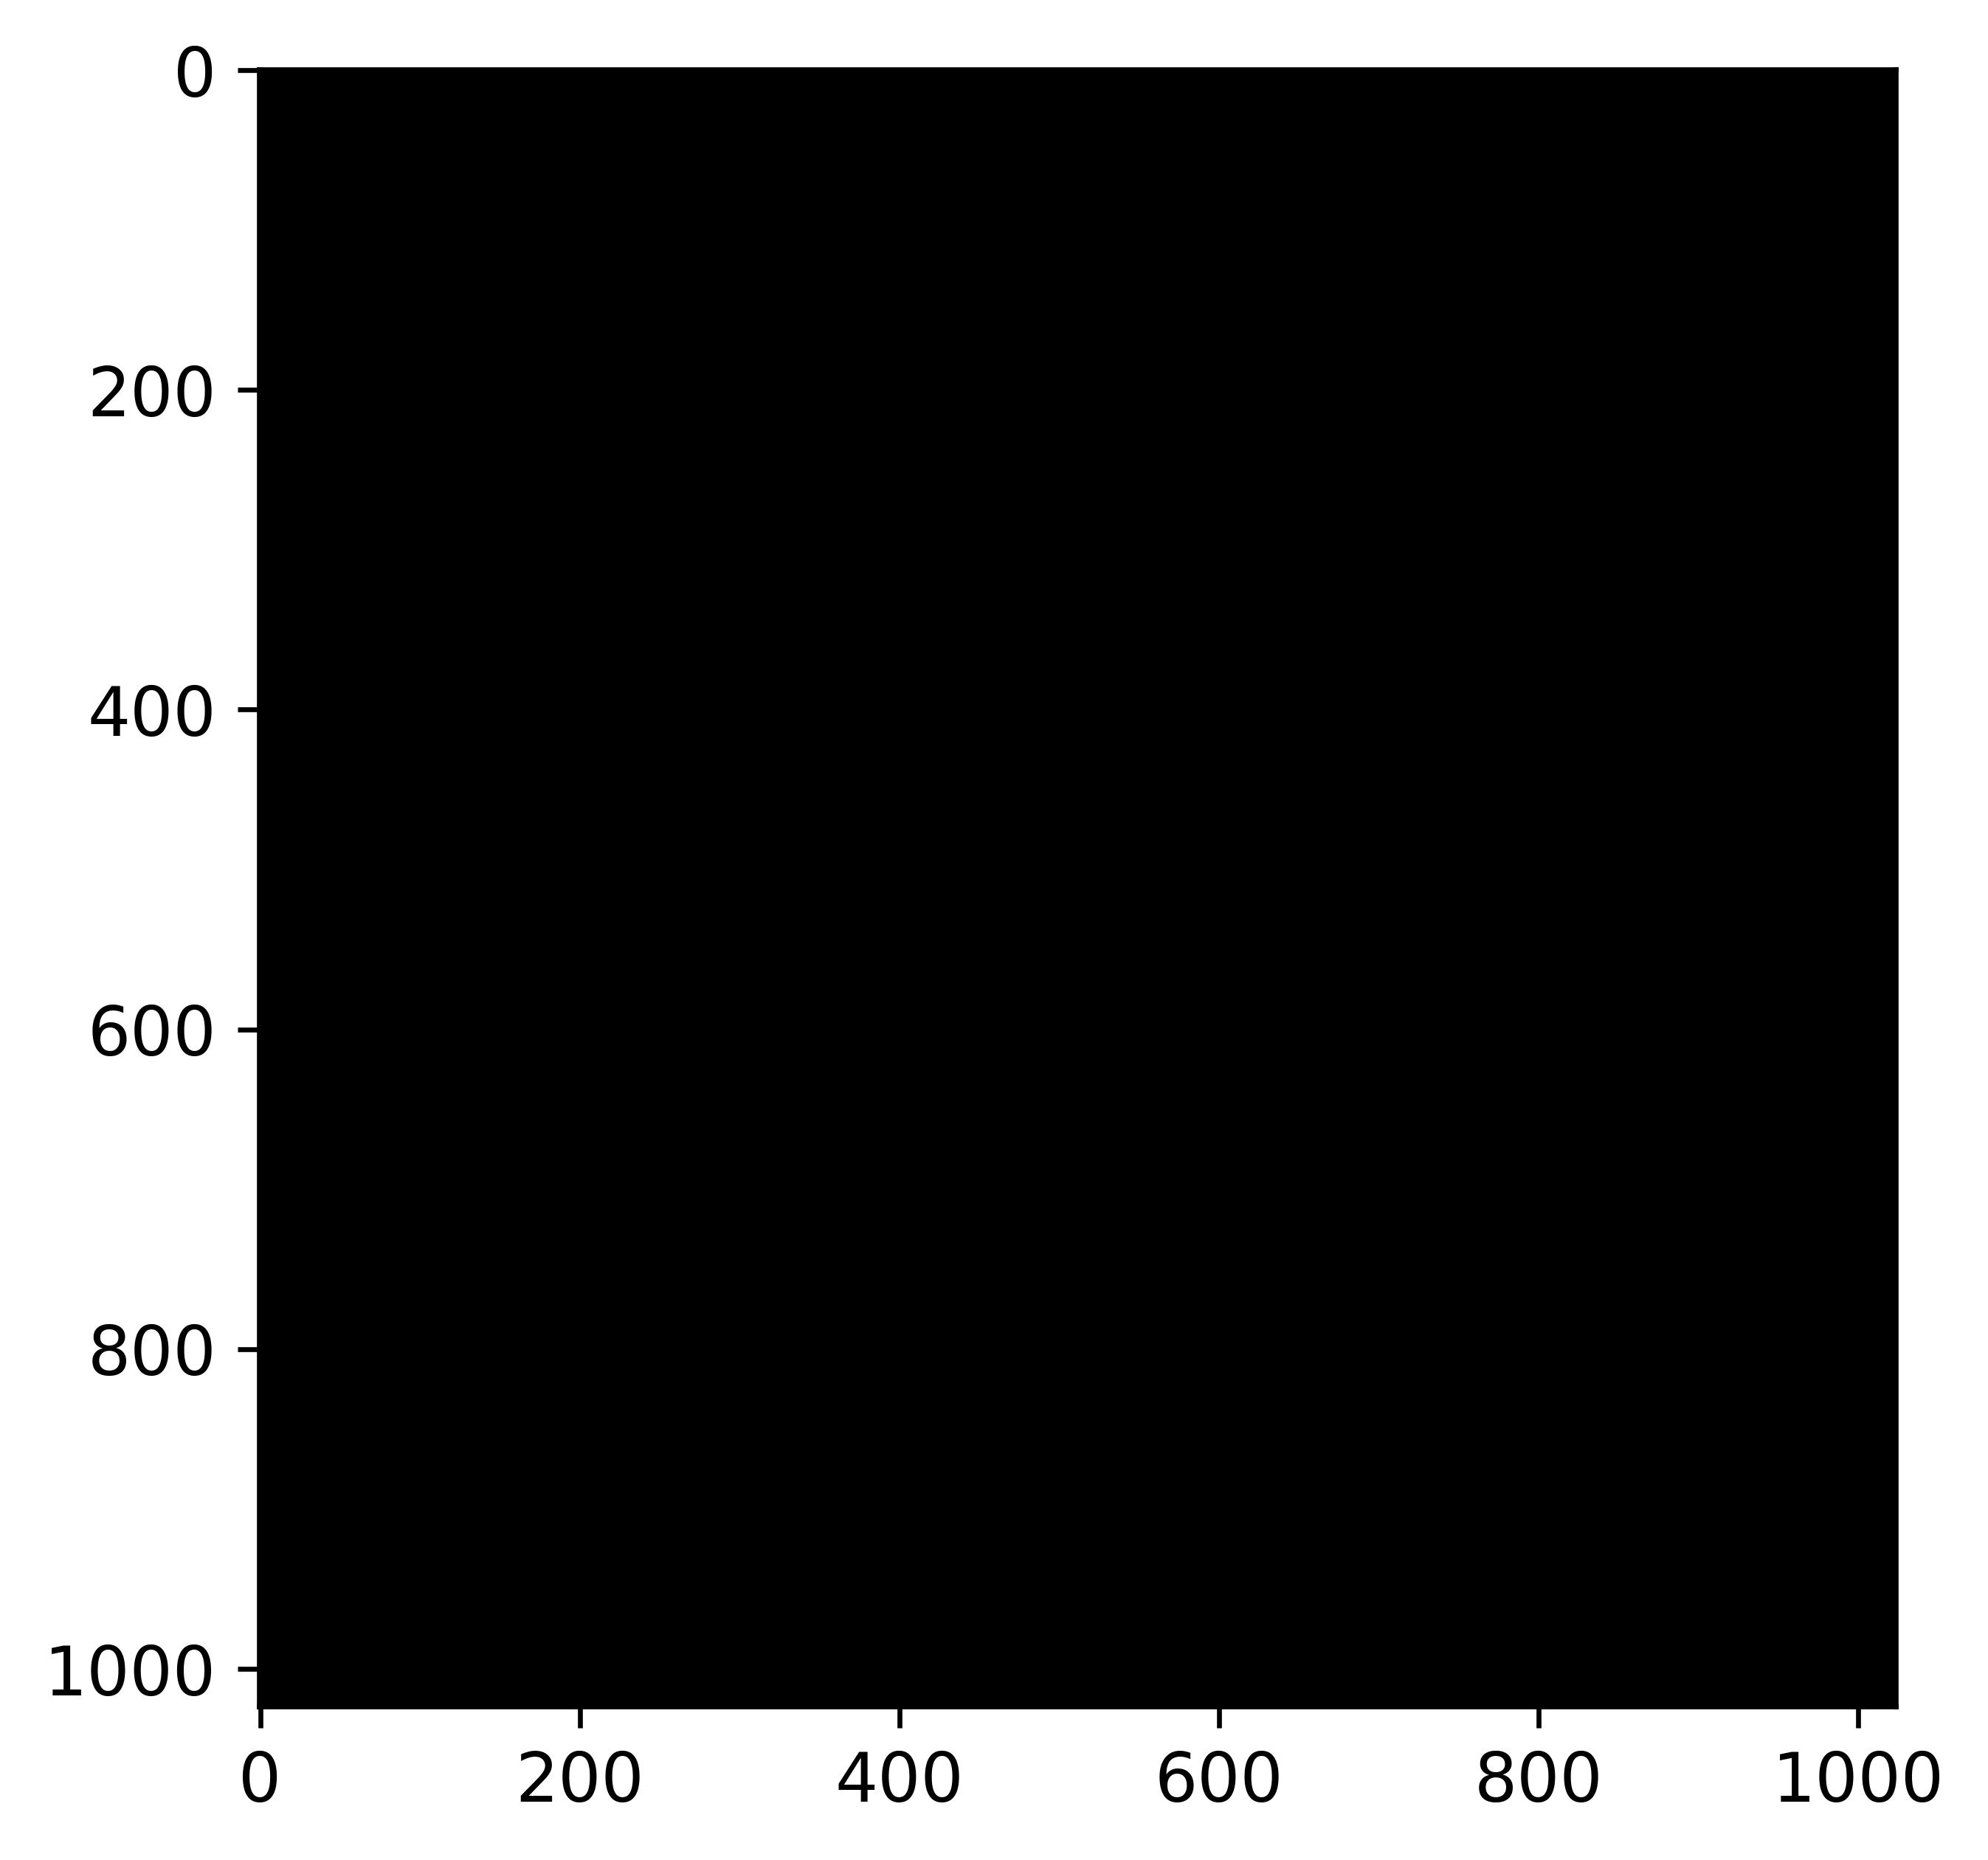

: 

In [ ]:
## TODO: load the model
model_dir = LOGS /  'run'
data_dir = '10-2900-control-cell-05.oif-C0.v3dpbd.tif'
model = torch.load(model_dir / 'best_20260501.pth')

# reconstruct the volume from the model's Gaussians, without model.reconstruction
means  = model["means"].to('cuda')
scales = torch.exp(model["log_scales"].to('cuda'))
intens  = F.softplus(model["intensities"].to('cuda'))

gaussians = torch.zeros((means.shape[0], 10), dtype=torch.float32)
gaussians[:, :3] = means          # x, y, z
gaussians[:, 3:6] = scales        # r_x, r_y, r_z
gaussians[:, 9] = intens           # alpha
# read tif file to get the original volume size
original_volume = tifffile.imread(resolve_path(data_dir))
# create an empty volume
volume_size = original_volume.shape
volume = torch.zeros(volume_size, dtype=torch.float32)
# render each Gaussian into the volume
for g in gaussians:
    x, y, z, r_x, r_y, r_z, r, g, b, alpha = g
    # create a Gaussian blob in the volume
    # (this is a simplified example; you may want to use a more accurate rendering method)
    x_min = max(int(x - 3*r_x), 0)
    x_max = min(int(x + 3*r_x), volume_size[0])
    y_min = max(int(y - 3*r_y), 0)
    y_max = min(int(y + 3*r_y), volume_size[1])
    z_min = max(int(z - 3*r_z), 0)
    z_max = min(int(z + 3*r_z), volume_size[2])
    for i in range(x_min, x_max):
        for j in range(y_min, y_max):
            for k in range(z_min, z_max):
                # compute the Gaussian value at (i,j,k)
                dx = (i - x) / r_x
                dy = (j - y) / r_y
                dz = (k - z) / r_z
                gaussian_value = alpha * torch.exp(-0.5 * (dx**2 + dy**2 + dz**2))
                volume[i,j,k] += gaussian_value
# normalize the volume to [0, 1]
rec_volume = torch.clamp(volume, 0, 1)
# save the volume as a TIFF file
print(rec_volume.shape)
plt.imshow(rec_volume[50].detach().cpu().numpy(), cmap='gray')

In [3]:
curves = {}
for run_dir in RUN_DIRS:
    run    = run_dir.name
    log    = json.loads((run_dir / 'log.json').read_text())
    log_df = pd.DataFrame(log)
    psnr_col = 'vol_psnr' if log_df['vol_psnr'].notna().any() else 'psnr'
    psnr = pd.to_numeric(log_df[psnr_col], errors='coerce').to_numpy()
    curves[run] = {
        'epoch':   log_df['epoch'].to_numpy(),
        'step':    log_df['step'].to_numpy(),
        'psnr':    psnr,
        'psnr_best': np.maximum.accumulate(np.where(np.isnan(psnr), -np.inf, psnr)),
        'n_gauss': log_df['n_gauss'].to_numpy() if 'n_gauss' in log_df.columns else None,
        'loss':    log_df['loss'].to_numpy() if 'loss' in log_df.columns else None,
        's_mean':  log_df['s_mean'].to_numpy() if 's_mean' in log_df.columns else None,
    }
    print(f'{run}: {len(log_df)} epochs, final PSNR {psnr[-1]:.2f} dB, best PSNR {np.nanmax(psnr):.2f} dB')


run: 1000 epochs, final PSNR 29.69 dB, best PSNR 42.18 dB


## 3 · Gaussian-count growth and densification schedule

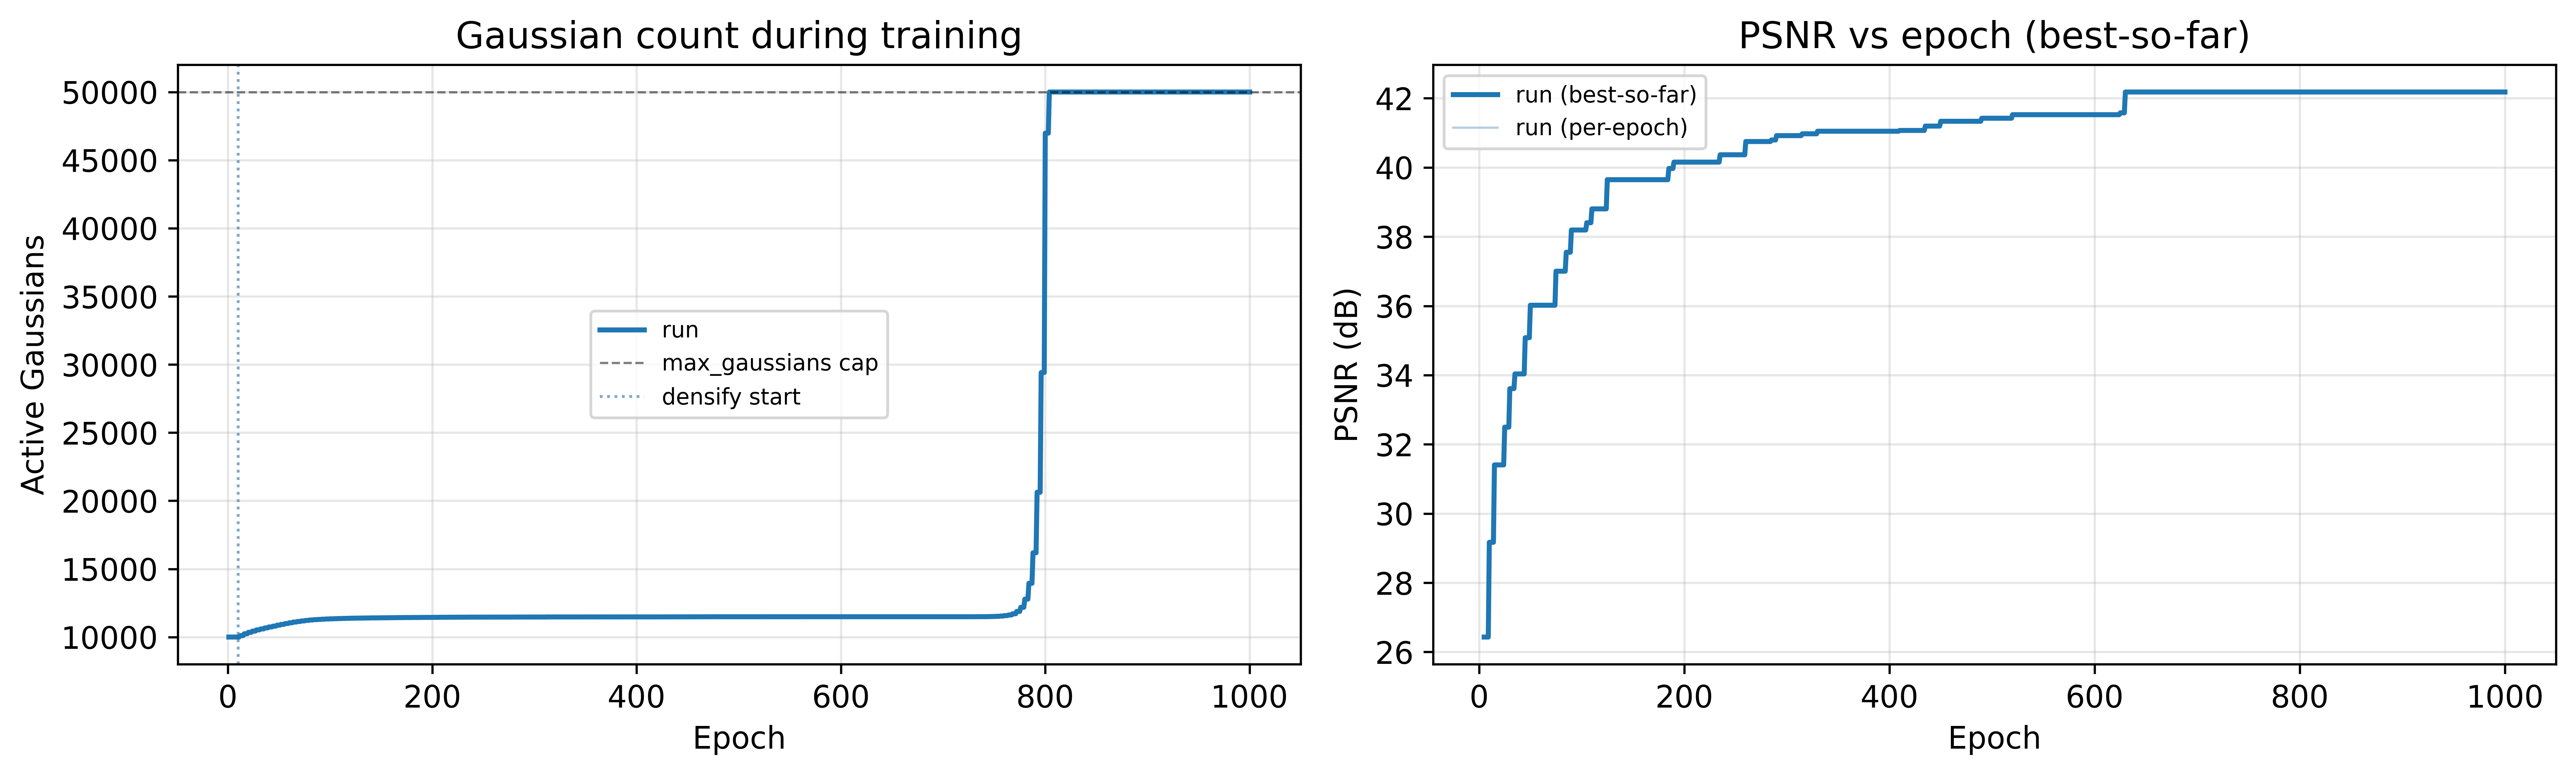

Saved -> /mnt/intelpa-1/armin/containers/storage/main/research_3/logs/3dgs/ablation/gaussian_count_growth.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for run, c in curves.items():
    row = df[df.run == run].iloc[0]
    axes[0].plot(c['epoch'], c['n_gauss'], linewidth=1.8, label=run)
    axes[0].axhline(row['max_gaussians'], color='k', linestyle='--', linewidth=0.8, alpha=0.5, label='max_gaussians cap')
    if row['densify_from']:
        sp  = int(row['densify_from']) // int(DEFAULT_CFG.get('steps_per_epoch', 50))
        axes[0].axvline(sp, color='steelblue', linestyle=':', linewidth=1, alpha=0.7, label='densify start')
    if row['densify_until']:
        ep2 = int(row['densify_until']) // int(DEFAULT_CFG.get('steps_per_epoch', 50))
        axes[0].axvline(ep2, color='tomato', linestyle=':', linewidth=1, alpha=0.7, label='densify end')

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Active Gaussians')
axes[0].set_title('Gaussian count during training')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

for run, c in curves.items():
    axes[1].plot(c['epoch'], c['psnr_best'], linewidth=1.8, label=f'{run} (best-so-far)')
    axes[1].plot(c['epoch'], c['psnr'], linewidth=0.8, alpha=0.4, color='steelblue', label=f'{run} (per-epoch)')

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('PSNR (dB)')
axes[1].set_title('PSNR vs epoch (best-so-far)')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ABLATION / 'gaussian_count_growth.pdf', dpi=600, bbox_inches='tight')
plt.savefig(ABLATION / 'gaussian_count_growth.png', dpi=250, bbox_inches='tight')
plt.show()
print(f'Saved -> {ABLATION / "gaussian_count_growth.png"}')


## 4 · Scale statistics over training

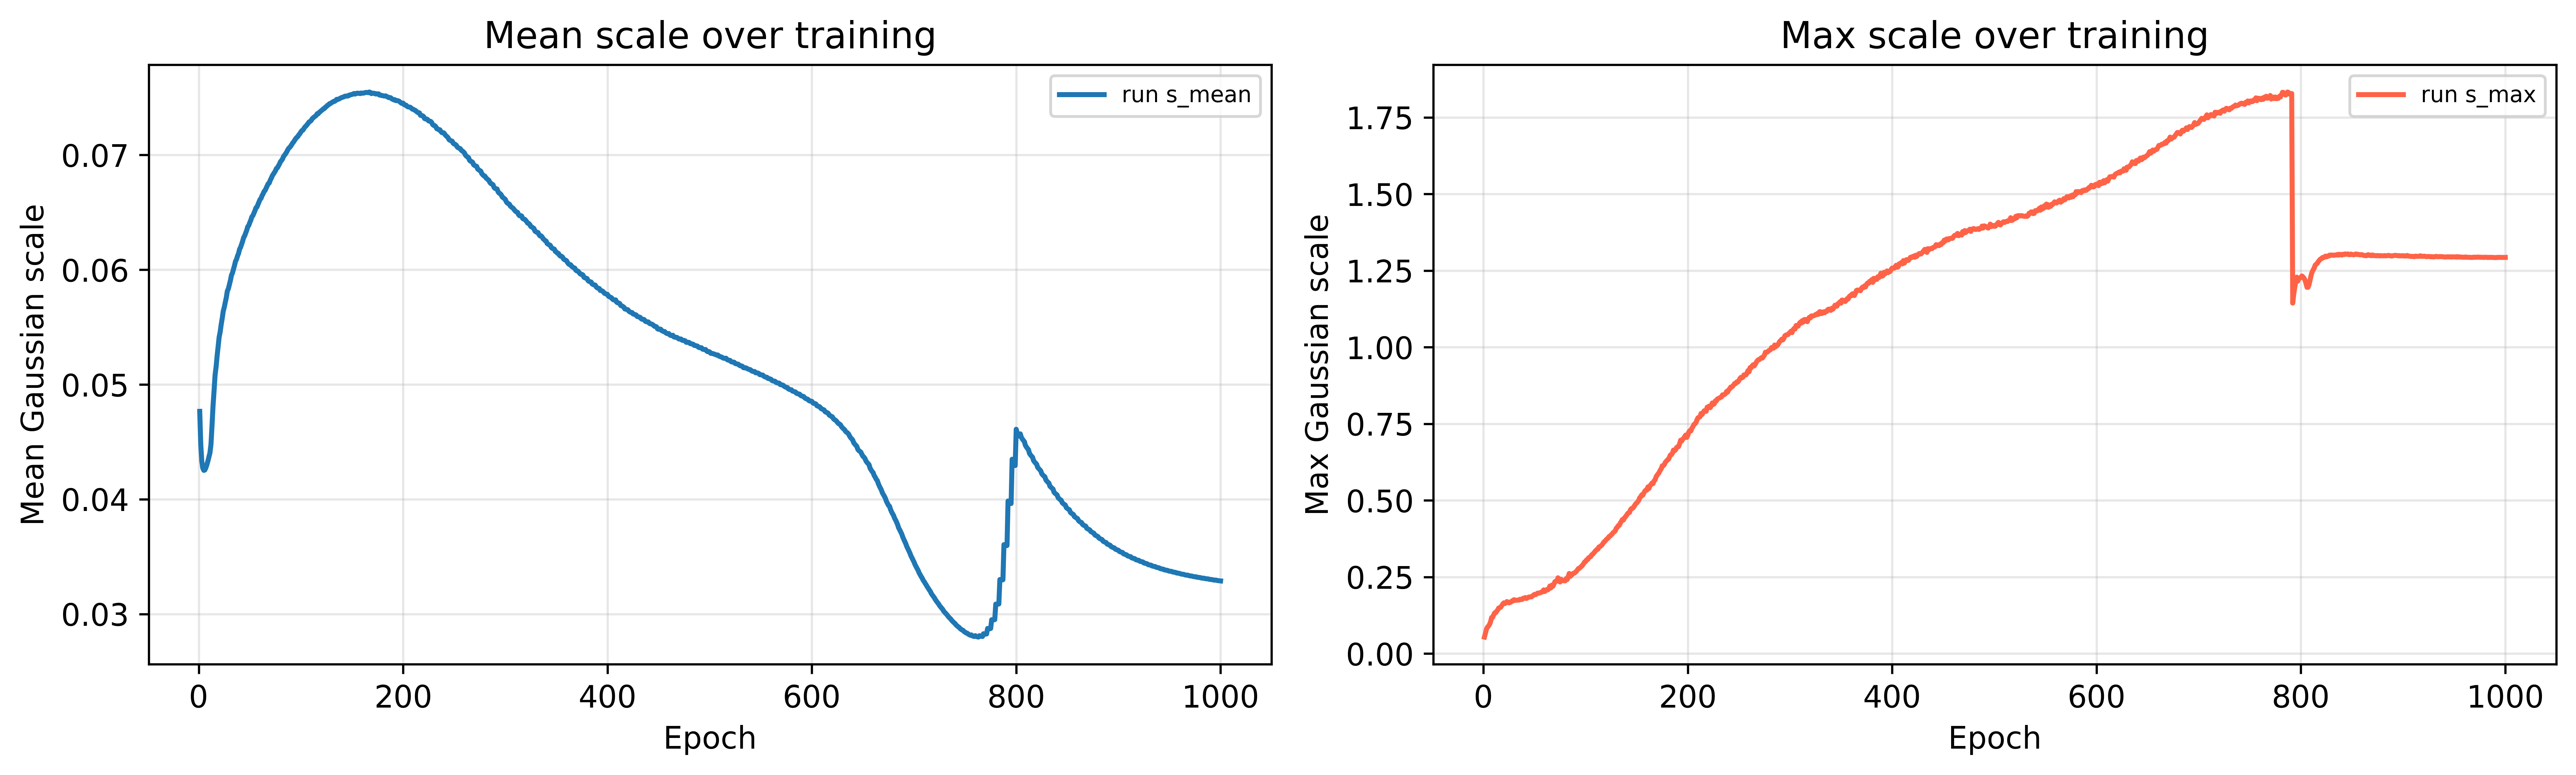

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for run_dir in RUN_DIRS:
    run    = run_dir.name
    log    = json.loads((run_dir / 'log.json').read_text())
    log_df = pd.DataFrame(log)

    if 's_mean' in log_df.columns:
        axes[0].plot(log_df['epoch'], log_df['s_mean'], linewidth=1.8, label=f'{run} s_mean')
    if 's_max' in log_df.columns:
        axes[1].plot(log_df['epoch'], log_df['s_max'], linewidth=1.8, label=f'{run} s_max', color='tomato')

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Mean Gaussian scale'); axes[0].set_title('Mean scale over training')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Max Gaussian scale'); axes[1].set_title('Max scale over training')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ABLATION / 'scale_stats.pdf', dpi=600, bbox_inches='tight')
plt.savefig(ABLATION / 'scale_stats.png', dpi=250, bbox_inches='tight')
plt.show()


## 5 · Intensity statistics over training

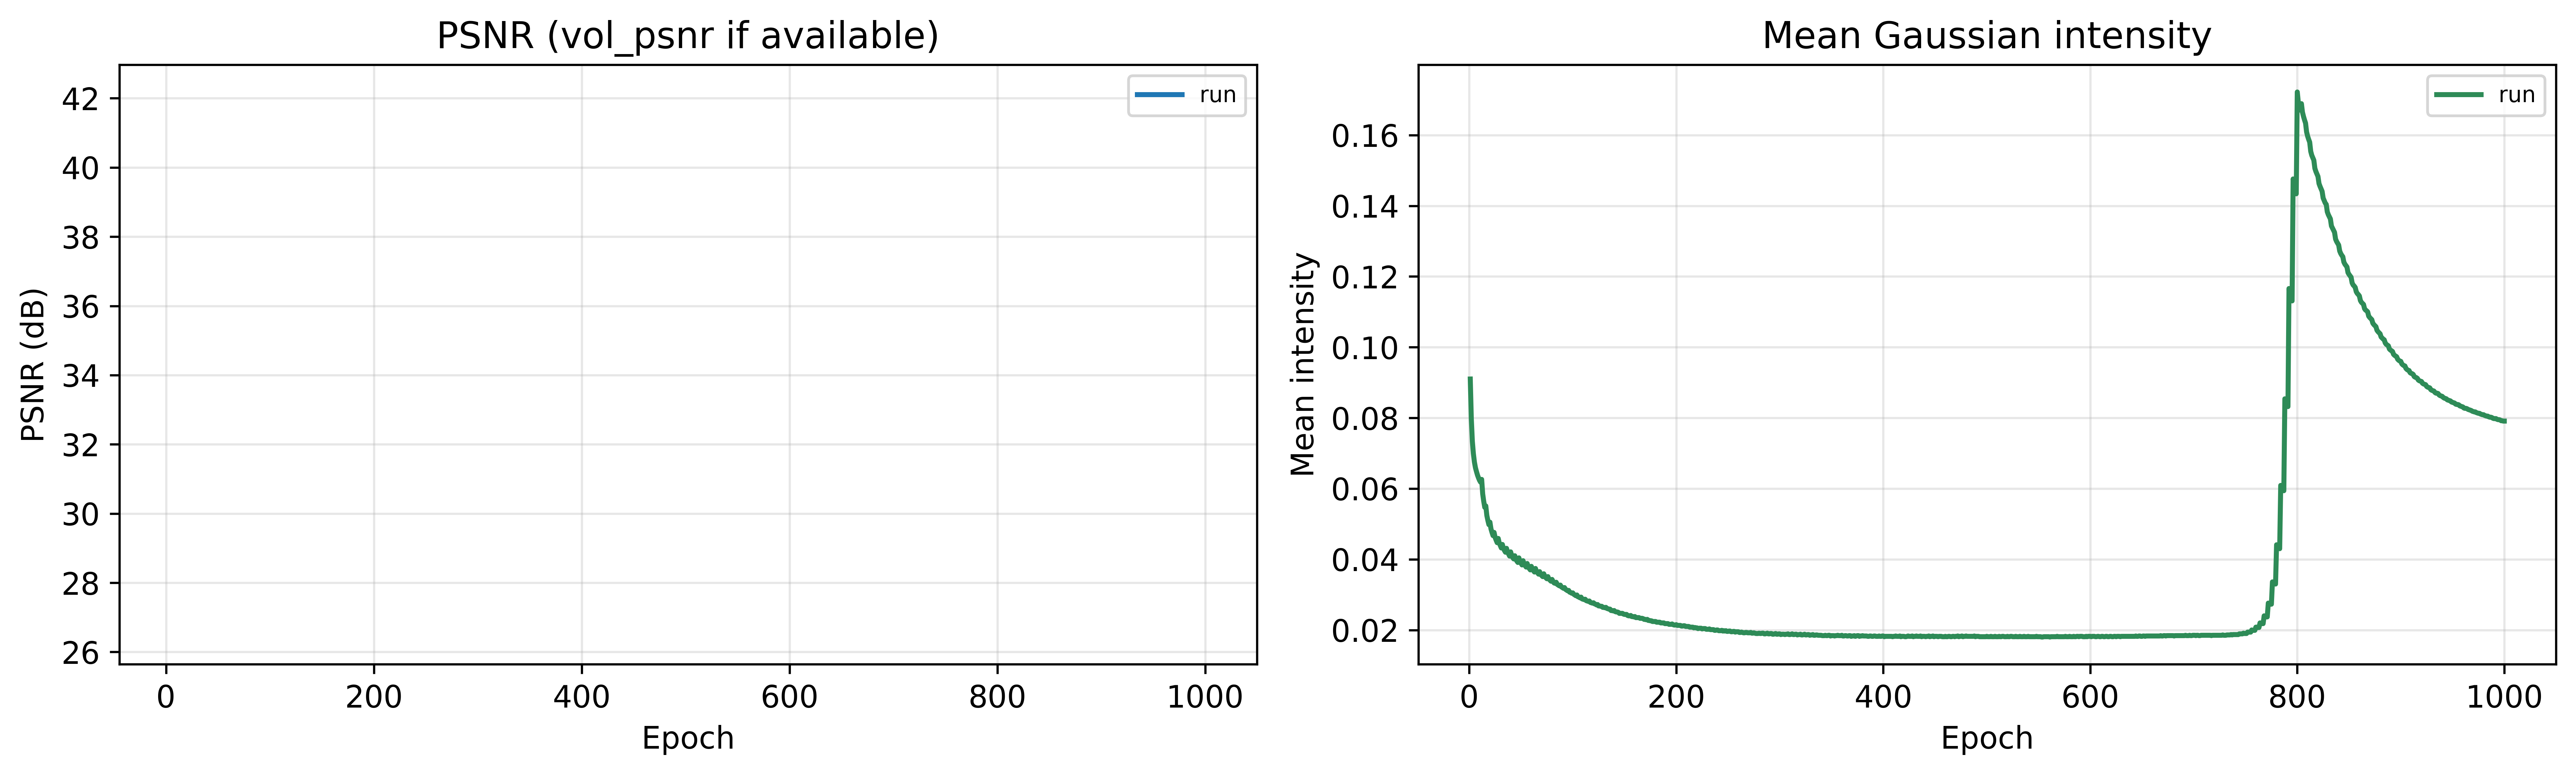

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for run_dir in RUN_DIRS:
    run    = run_dir.name
    log    = json.loads((run_dir / 'log.json').read_text())
    log_df = pd.DataFrame(log)

    psnr_col = 'vol_psnr' if log_df['vol_psnr'].notna().any() else 'psnr'
    axes[0].plot(log_df['epoch'], pd.to_numeric(log_df[psnr_col], errors='coerce'), linewidth=1.8, label=run)
    if 'inten_mean' in log_df.columns:
        axes[1].plot(log_df['epoch'], log_df['inten_mean'], linewidth=1.8, label=run, color='seagreen')

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('PSNR (dB)'); axes[0].set_title('PSNR (vol_psnr if available)')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean intensity'); axes[1].set_title('Mean Gaussian intensity')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ABLATION / 'intensity_stats.pdf', dpi=600, bbox_inches='tight')
plt.savefig(ABLATION / 'intensity_stats.png', dpi=250, bbox_inches='tight')
plt.show()


## 6 · Efficiency — PSNR vs Gaussian count & training time

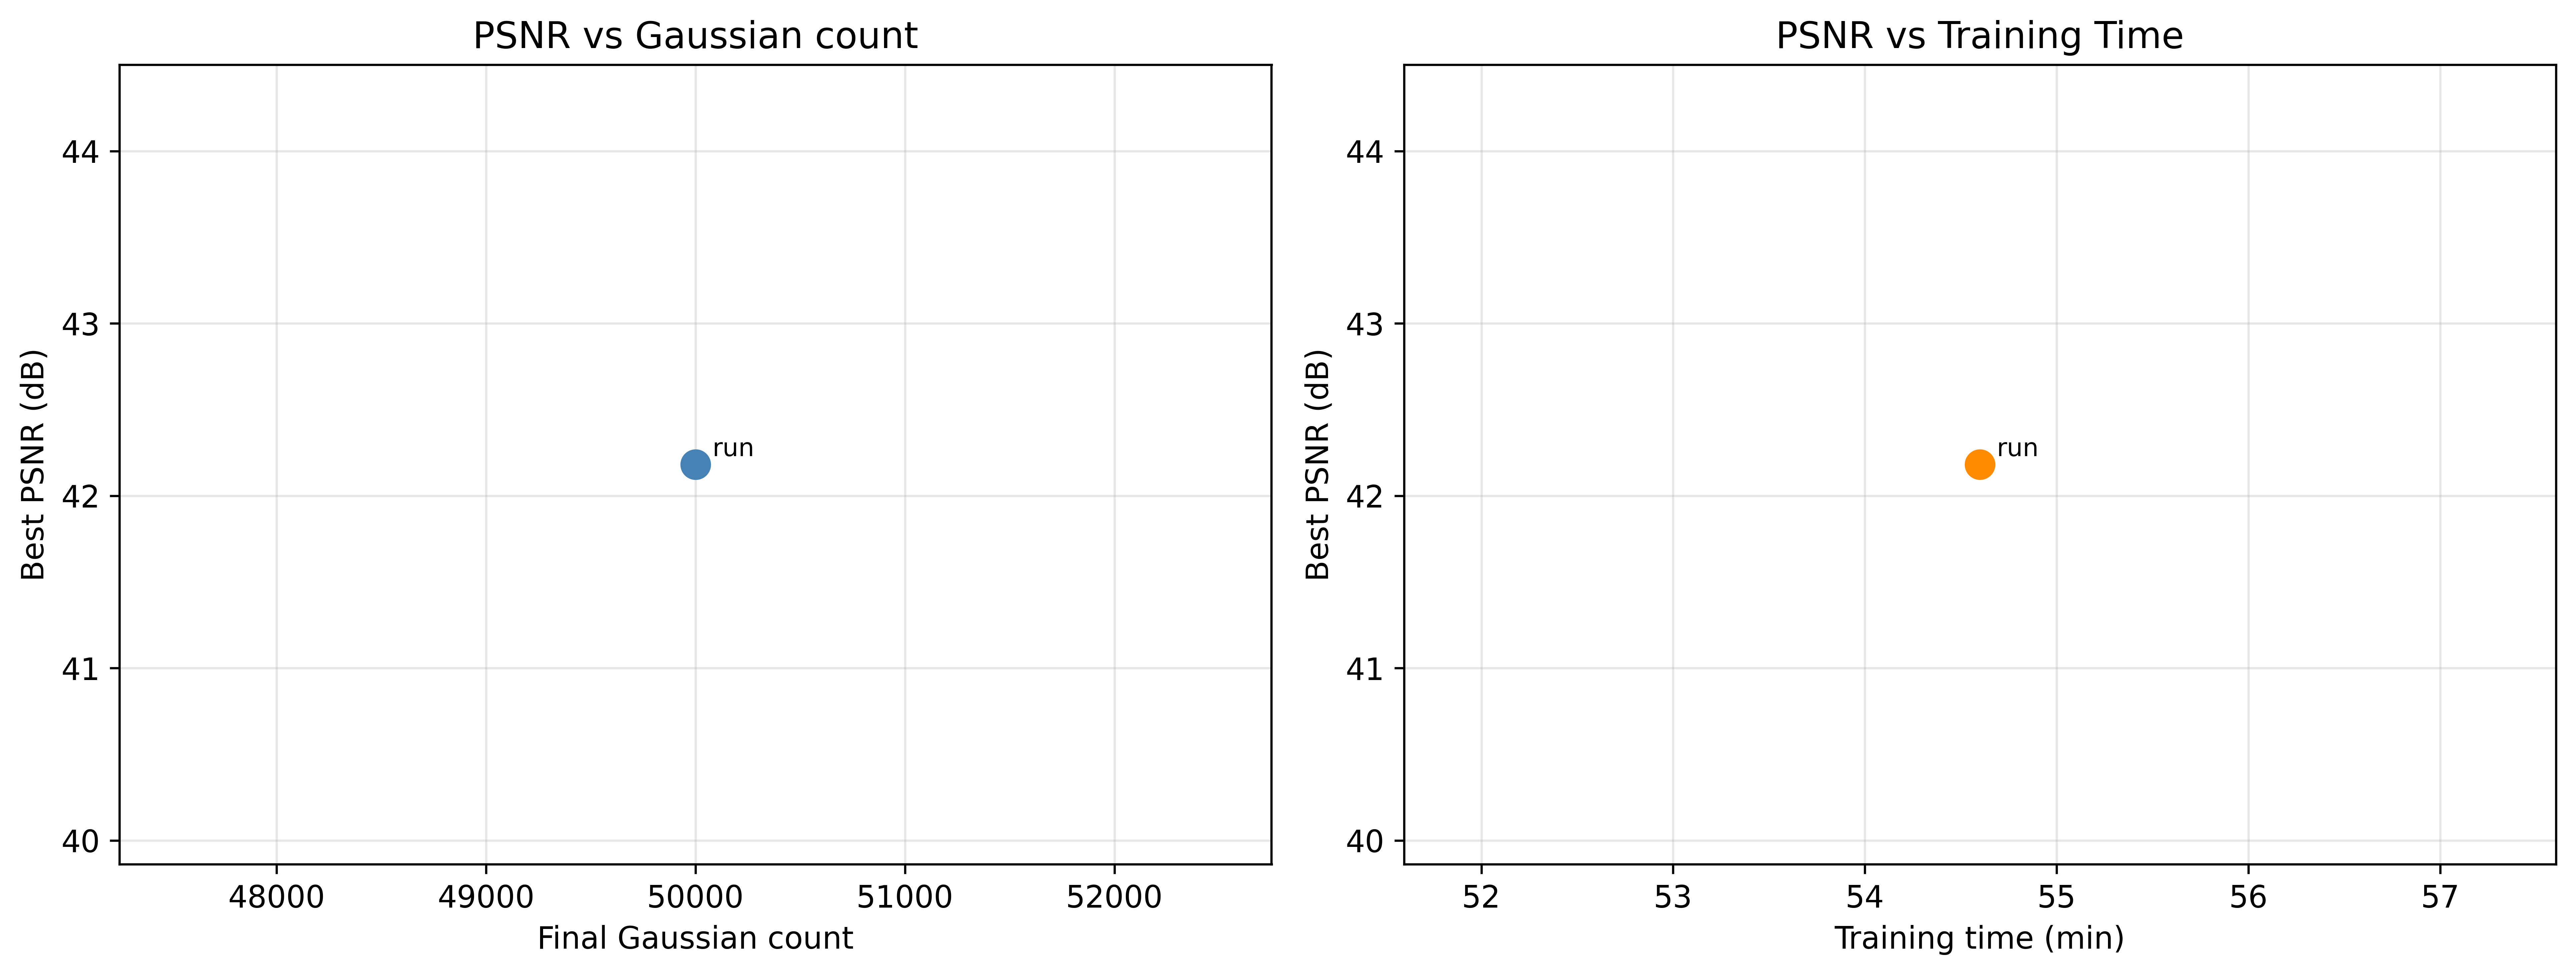

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(df['final_n_gauss'], df['best_psnr'], s=100, c='steelblue', zorder=3)
for _, row in df.iterrows():
    ax.annotate(row['run'], (row['final_n_gauss'], row['best_psnr']),
                textcoords='offset points', xytext=(6, 3), fontsize=9)
ax.set_xlabel('Final Gaussian count')
ax.set_ylabel('Best PSNR (dB)')
ax.set_title('PSNR vs Gaussian count')
ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(df['train_min'], df['best_psnr'], s=100, c='darkorange', zorder=3)
for _, row in df.iterrows():
    ax.annotate(row['run'], (row['train_min'], row['best_psnr']),
                textcoords='offset points', xytext=(6, 3), fontsize=9)
ax.set_xlabel('Training time (min)')
ax.set_ylabel('Best PSNR (dB)')
ax.set_title('PSNR vs Training Time')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ABLATION / 'efficiency.pdf', dpi=600, bbox_inches='tight')
plt.savefig(ABLATION / 'efficiency.png', dpi=250, bbox_inches='tight')
plt.show()


## 7 · All training curves

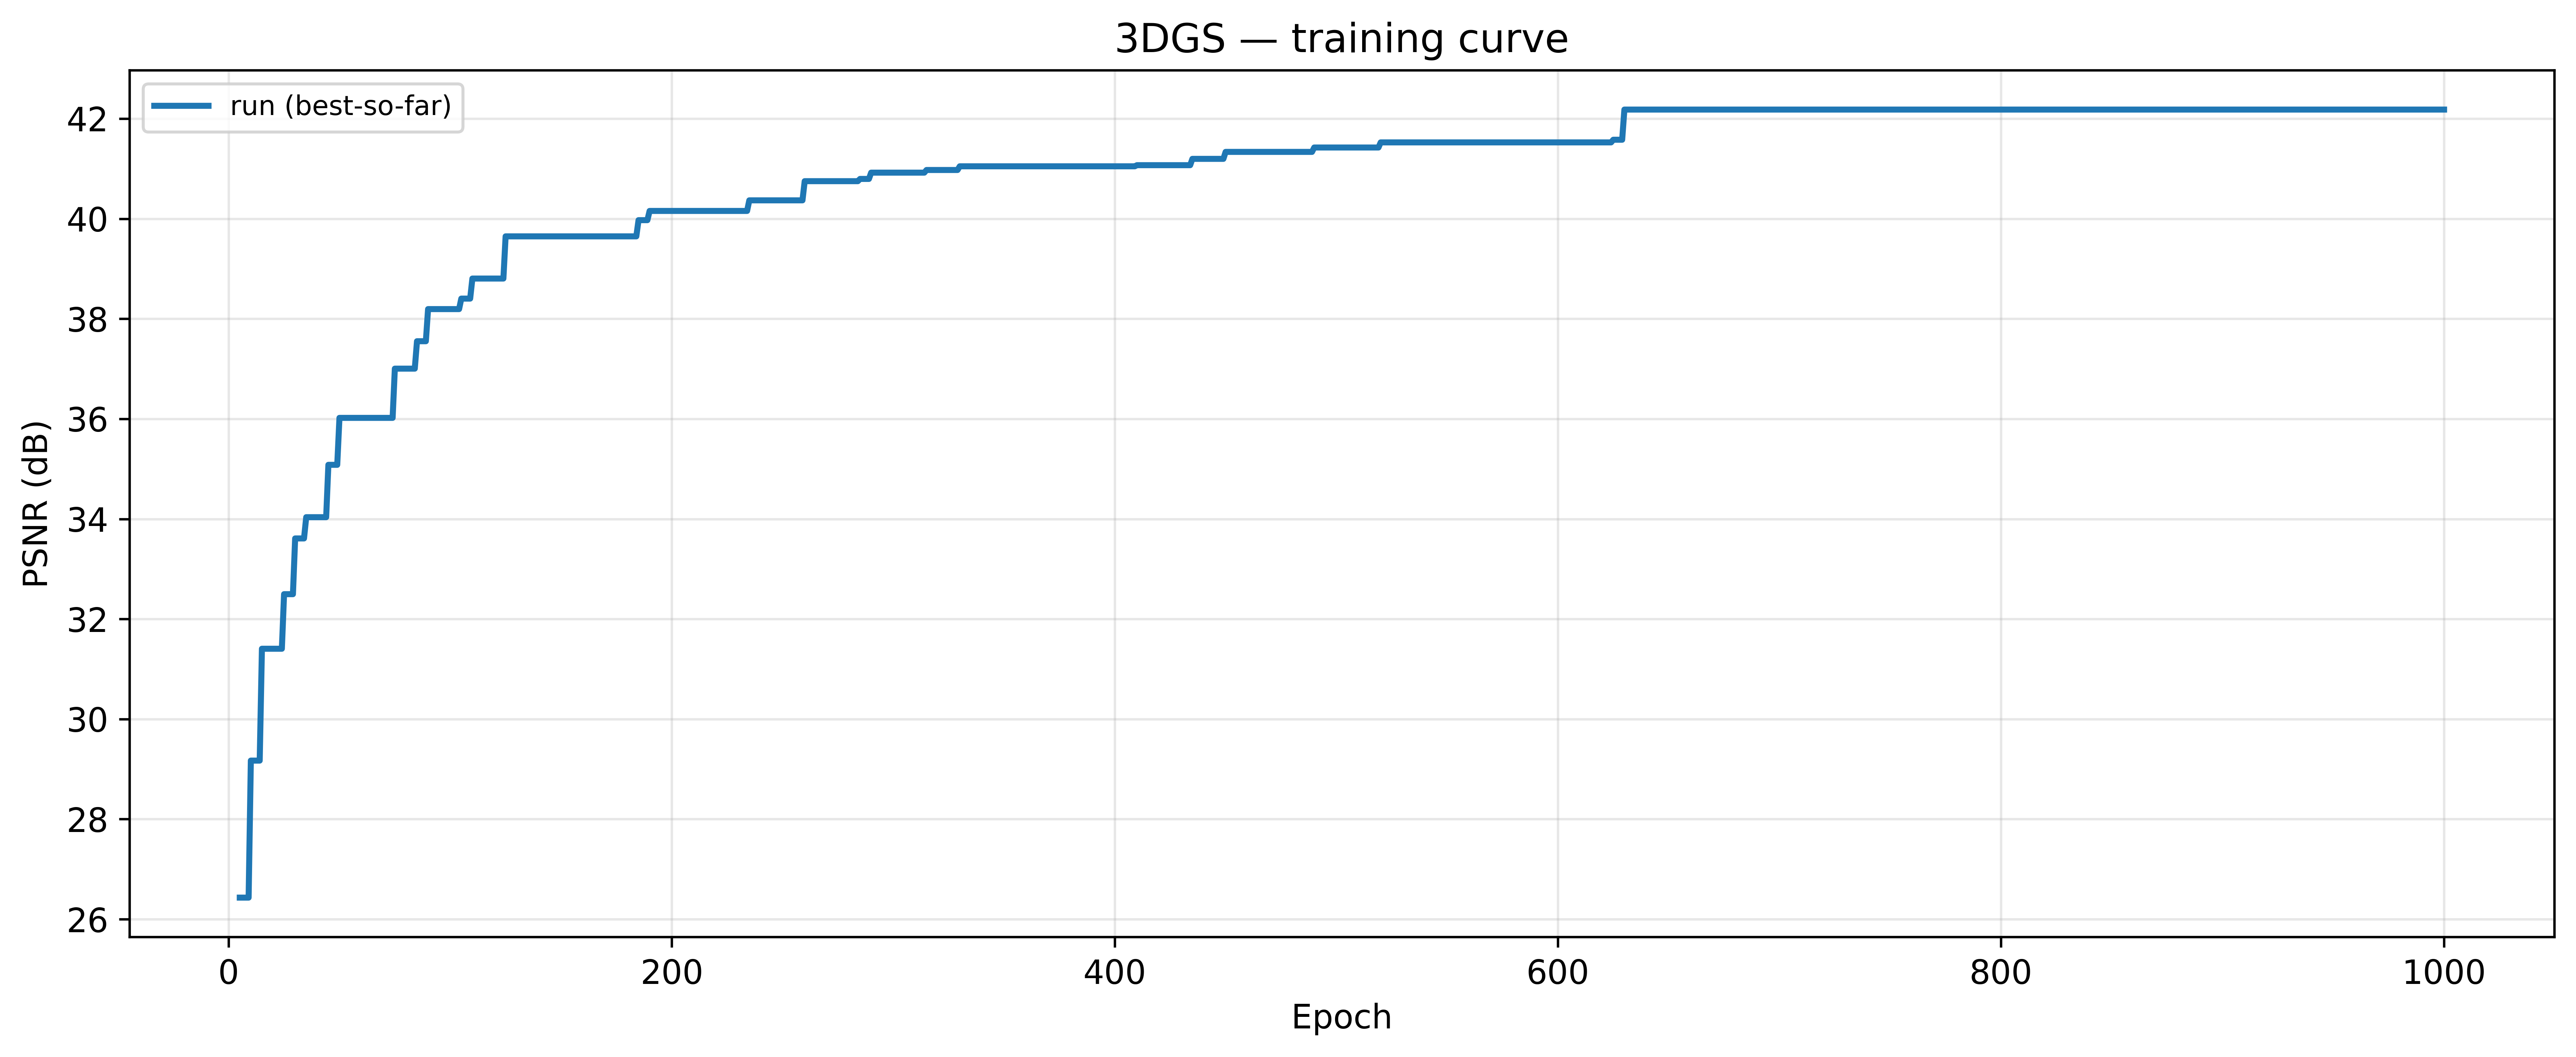

Saved -> /mnt/intelpa-1/armin/containers/storage/main/research_3/logs/3dgs/ablation/all_curves.png


In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
for run, c in sorted(curves.items()):
    ax.plot(c['epoch'], c['psnr_best'], linewidth=2.0, label=f'{run} (best-so-far)')
    ax.plot(c['epoch'], c['psnr'], linewidth=0.8, alpha=0.35, linestyle='--')

ax.set_xlabel('Epoch')
ax.set_ylabel('PSNR (dB)')
ax.set_title('3DGS — training curve')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ABLATION / 'all_curves.pdf', dpi=600, bbox_inches='tight')
plt.savefig(ABLATION / 'all_curves.png', dpi=250, bbox_inches='tight')
plt.show()
print(f'Saved -> {ABLATION / "all_curves.png"}')


## 8 · Summary table + export CSV

In [16]:
has_metrics = df['ssim'].notna().any()
cols    = ['run', 'n_init', 'max_gaussians', 'best_psnr', 'final_n_gauss', 'epochs_trained', 'train_min']
renames = {'best_psnr': 'PSNR (dB)', 'final_n_gauss': 'N gaussians', 'epochs_trained': 'epochs', 'train_min': 'time (min)'}
if has_metrics:
    cols = cols[:4] + ['ssim', 'lpips'] + cols[4:]
    renames.update({'ssim': 'SSIM ↑', 'lpips': 'LPIPS ↓'})

summary = df[cols].copy()
summary['best_psnr'] = summary['best_psnr'].round(2)
if has_metrics:
    summary['ssim']  = summary['ssim'].map(lambda v: f'{v:.4f}' if v is not None else 'N/A')
    summary['lpips'] = summary['lpips'].map(lambda v: f'{v:.4f}' if v is not None else 'N/A')
summary = summary.rename(columns=renames)
summary.to_csv(ABLATION / 'results.csv', index=False)
from IPython.display import display
display(summary)
print(f'Saved -> {ABLATION / "results.csv"}')


,run,n_init,max_gaussians,PSNR (dB),N gaussians,epochs,time (min)
0,run,10000,50000,42.18,50000,1000,54.6


Saved -> /mnt/intelpa-1/armin/containers/storage/main/research_3/logs/3dgs/ablation/results.csv


## 9 · Setup — model loader, volume, coordinate grid

In [17]:
sys.path.insert(0, str(ROOT / 'src'))
spec = importlib.util.spec_from_file_location('gs3d', ROOT / 'src' / '3dgs.py')
gs3d = importlib.util.module_from_spec(spec)
spec.loader.exec_module(gs3d)

INPUT       = str(resolve_path(DEFAULT_CFG['volume']))
INFER_BATCH = 2**14   # 16 k points at a time to avoid OOM
SLICE_IDXS  = [20, 40, 60, 80]

vol_raw = tifffile.imread(INPUT).astype('float32')
vmin_v, vmax_v = vol_raw.min(), vol_raw.max()
gt_vol  = (vol_raw - vmin_v) / (vmax_v - vmin_v)
D, H, W = gt_vol.shape
gt_vol_t = torch.from_numpy(gt_vol)
SLICE_IDXS = [max(0, min(D-1, z)) for z in SLICE_IDXS]
print(f'Volume shape : {D} x {H} x {W}')
print(f'Slice indices: {SLICE_IDXS}')

def build_cfg_ns(run_dir, device='cpu'):
    cfg = dict(DEFAULT_CFG)
    cfg_path = run_dir / 'config.json'
    if cfg_path.exists():
        cfg.update(json.loads(cfg_path.read_text()))
    cfg['volume']    = str(resolve_path(cfg.get('volume', DEFAULT_CFG['volume'])))
    swc = cfg.get('swc_path')
    cfg['swc_path']  = None if swc is None else str(resolve_path(swc))
    cfg['device']    = device
    cfg['use_kernel'] = False
    for key, default in [('chunk_n', 1024), ('scale_min_clamp', 1e-5),
                         ('mahal_max_clamp', 20.0), ('eval_samples', 10000)]:
        cfg.setdefault(key, DEFAULT_CFG.get(key, default))
    return SimpleNamespace(**cfg)

def find_best_ckpt(run_dir):
    for pattern in ('best_*.pth', 'best.pth', 'best.npz'):
        hits = sorted(run_dir.glob(pattern))
        if hits:
            return hits[0]
    return None

def load_cloud(run_dir, device='cpu'):
    ckpt = find_best_ckpt(run_dir)
    assert ckpt is not None, f'No best checkpoint in {run_dir}'
    cfg  = build_cfg_ns(run_dir, device=device)
    gs3d.USE_CUDA_KERNEL = False
    aabb = gs3d.AABB.unit()
    dataset = gs3d.VolumeDataset(gt_vol_t, aabb, cfg, swc_path=cfg.swc_path)
    gc = gs3d.GaussianCloud.load(ckpt, aabb, torch.device(device), cfg)
    return gc, dataset, cfg

def render_slice(gc, dataset, z_idx, cfg, batch=INFER_BATCH):
    H, W = dataset.H, dataset.W
    rows = torch.arange(H, dtype=torch.long).repeat_interleave(W)
    cols = torch.arange(W, dtype=torch.long).tile(H)
    depth = torch.full((H * W,), int(z_idx), dtype=torch.long)
    pred = np.empty(H * W, dtype='float32')
    with torch.no_grad():
        for s in range(0, H * W, batch):
            e = min(s + batch, H * W)
            pts = dataset._indices_to_pts(depth[s:e], rows[s:e], cols[s:e], gc.device)
            pred[s:e] = gc.forward(pts, chunk_n=getattr(cfg, 'chunk_n', 1024)).clamp(0, 1).cpu().numpy()
    return pred.reshape(H, W)

def reconstruct_vol(gc, dataset, cfg, desc='render volume'):
    """Render the full (D, H, W) volume from GaussianCloud on its own device.
    Shows a tqdm bar; moves result to CPU numpy.
    """
    from tqdm.auto import tqdm
    vol = np.empty((dataset.D, dataset.H, dataset.W), dtype='float32')
    for z in tqdm(range(dataset.D), desc=desc, leave=True):
        vol[z] = render_slice(gc, dataset, z, cfg)
    if gc.device.type == 'cuda':
        torch.cuda.empty_cache()
    return vol

import lpips as lpips_lib
lpips_fn = lpips_lib.LPIPS(net='alex').eval()
LPIPS_SZ = 256


Volume shape : 113 x 1024 x 1024
Slice indices: [20, 40, 60, 80]
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/armin/miniconda3/envs/mink/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/armin/miniconda3/envs/mink/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/armin/miniconda3/envs/mink/lib/python3.8/site-packages/lpips/weights/v0.1/alex.pth


/home/armin/miniconda3/envs/mink/lib/python3.8/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path, ma

## 10 · SSIM & LPIPS

In [20]:
from skimage.metrics import structural_similarity
from tqdm.auto import tqdm
N_LPIPS_SLICES = 20

metrics_rows = []
for _, row in df.iterrows():
    run_dir      = LOGS / row['run']
    metrics_path = run_dir / 'metrics.json'

    if metrics_path.exists():
        m = json.loads(metrics_path.read_text())
        print(f"{row['run']}: cached  SSIM={m['ssim']:.4f}  LPIPS={m['lpips']:.4f}")
        metrics_rows.append({'run': row['run'], **m})
        continue

    dev = 'cuda' if torch.cuda.is_available() else 'cpu'
    gc, dataset, cfg = load_cloud(run_dir, device=dev)

    z_sample = np.linspace(0, dataset.D - 1, N_LPIPS_SLICES, dtype=int)

    ssim_vals, lpips_vals = [], []
    for z in tqdm(z_sample, desc=f"{row['run']}  SSIM+LPIPS", leave=True):
        pred_sl = render_slice(gc, dataset, int(z), cfg)
        gt_sl   = gt_vol[z]

        ssim_vals.append(float(structural_similarity(gt_sl, pred_sl, data_range=1.0)))

        def to_rgb(sl):
            t = torch.from_numpy(sl).float().unsqueeze(0).unsqueeze(0)
            t = F.interpolate(t, size=(LPIPS_SZ, LPIPS_SZ), mode='bilinear', align_corners=False)
            return t.repeat(1, 3, 1, 1) * 2 - 1
        with torch.no_grad():
            lpips_vals.append(float(lpips_fn(to_rgb(gt_sl), to_rgb(pred_sl)).item()))

    m = {'ssim': round(float(np.mean(ssim_vals)), 4),
         'lpips': round(float(np.mean(lpips_vals)), 4)}
    metrics_path.write_text(json.dumps(m, indent=2))
    print(f"{row['run']}: SSIM={m['ssim']:.4f}  LPIPS={m['lpips']:.4f}")
    metrics_rows.append({'run': row['run'], **m})

    del gc, dataset, cfg
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

metrics_df = pd.DataFrame(metrics_rows)
df = df.merge(metrics_df[['run','ssim','lpips']], on='run', how='left', suffixes=('_old',''))
for col in ('ssim','lpips'):
    if f'{col}_old' in df.columns:
        df[col] = df[col].combine_first(df[f'{col}_old'])
        df.drop(columns=[f'{col}_old'], inplace=True)


/mnt/intelpa-1/armin/containers/storage/main/research_3/src/3dgs.py:777: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(str(path), map_location="cpu")


run  SSIM+LPIPS:   0%|          | 0/20 [00:00<?, ?it/s]

run: SSIM=0.9205  LPIPS=0.0752


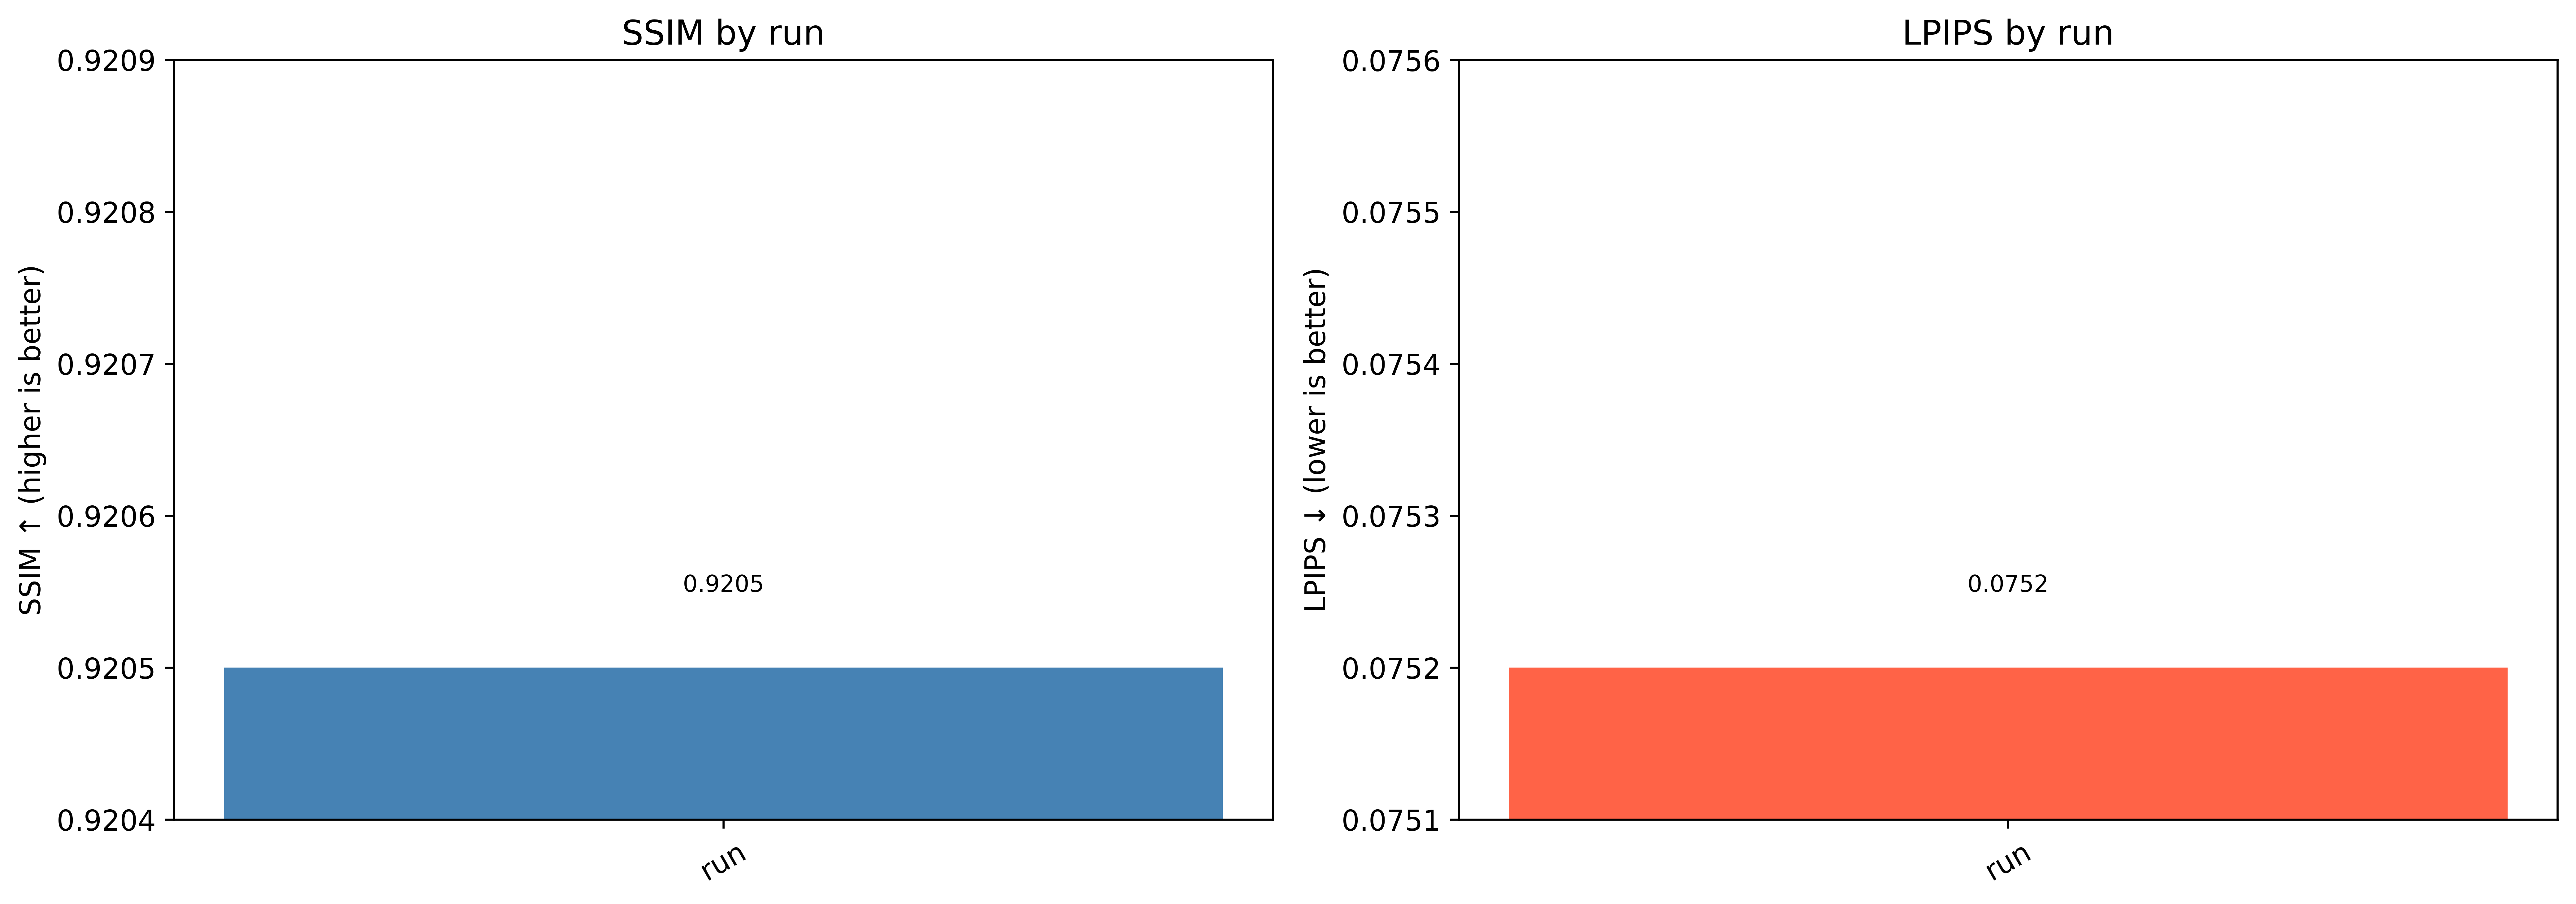

Saved -> /mnt/intelpa-1/armin/containers/storage/main/research_3/logs/3dgs/ablation/ssim_lpips.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, label, color, ascending in [
    (axes[0], 'ssim',  'SSIM ↑ (higher is better)', 'steelblue', False),
    (axes[1], 'lpips', 'LPIPS ↓ (lower is better)', 'tomato',    True),
]:
    vals = df[col].dropna()
    if vals.empty:
        ax.set_title(f'{col.upper()} — no data'); continue
    ordered = df.sort_values(col, ascending=ascending).reset_index(drop=True)
    bars = ax.bar(ordered['run'], ordered[col], color=color, width=0.6)
    ax.set_ylabel(label)
    ax.set_title(f'{col.upper()} by run')
    ax.tick_params(axis='x', rotation=30)
    pad = max((ordered[col].max() - ordered[col].min()) * 0.03, 1e-4)
    ax.set_ylim(ordered[col].min() - pad, ordered[col].max() + pad * 4)
    for bar, v in zip(bars, ordered[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + pad * 0.5,
                f'{v:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(ABLATION / 'ssim_lpips.pdf', dpi=600, bbox_inches='tight')
plt.savefig(ABLATION / 'ssim_lpips.png', dpi=250, bbox_inches='tight')
plt.show()
print(f'Saved -> {ABLATION / "ssim_lpips.png"}')


## 9 · Volume reconstruction — GT / Recon / Diff  (slices 20 · 40 · 60 · 80)

In [23]:
from tqdm.auto import tqdm as _tqdm

for _, row in df.iterrows():
    run_dir = LOGS / row['run']
    dev = 'cuda' if torch.cuda.is_available() else 'cpu'
    gc, dataset, cfg = load_cloud(run_dir, device=dev)

    recon_slices = {}
    for z in _tqdm(SLICE_IDXS, desc=f"{row['run']}  slices", leave=True):
        recon_slices[z] = render_slice(gc, dataset, z, cfg)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    psnr_full = float(-10 * np.log10(
        np.mean([(recon_slices[z] - gt_vol[z])**2 for z in SLICE_IDXS]) + 1e-8))

    fig, axes_grid = plt.subplots(3, len(SLICE_IDXS), figsize=(4 * len(SLICE_IDXS), 10))
    fig.suptitle(f"{row['run']}  |  best PSNR={row['best_psnr']:.2f} dB  "
                 f"N={row['final_n_gauss']:,}  t={row['train_min']:.0f} min", fontsize=13)

    for col, z in enumerate(SLICE_IDXS):
        gt_sl   = gt_vol[z]
        pred_sl = recon_slices[z]
        diff_sl = np.abs(gt_sl - pred_sl)
        mse_z   = float(np.mean((gt_sl - pred_sl)**2))
        psnr_z  = -10 * np.log10(mse_z + 1e-8)

        axes_grid[0, col].imshow(gt_sl,   cmap='gray', vmin=0, vmax=1)
        axes_grid[0, col].set_title(f'GT  z={z}', fontsize=9)
        axes_grid[0, col].axis('off')

        axes_grid[1, col].imshow(pred_sl, cmap='gray', vmin=0, vmax=1)
        axes_grid[1, col].set_title(f'Recon  {psnr_z:.1f} dB', fontsize=9)
        axes_grid[1, col].axis('off')

        vmax_d = float(diff_sl.max()) if float(diff_sl.max()) > 0 else 1e-6
        axes_grid[2, col].imshow(diff_sl, cmap='inferno', vmin=0, vmax=vmax_d)
        axes_grid[2, col].set_title(f'|Diff|  max={vmax_d:.3f}', fontsize=9)
        axes_grid[2, col].axis('off')

    for i, label in enumerate(['GT', 'Recon', '|Diff|' ]):
        axes_grid[i, 0].set_ylabel(label, rotation=0, ha='right', va='center', labelpad=28)

    plt.tight_layout()
    out = ABLATION / f'recon_{row["run"]}.pdf'
    plt.savefig(out, dpi=600, bbox_inches='tight')
    plt.savefig(str(out).replace('.pdf','.png'), dpi=600, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {out}')
    del gc, dataset, cfg


Processing run...


KeyboardInterrupt: 

## 9b · Maximum Intensity Projection (MIP) — XY · XZ · ZY

In [25]:
from tqdm.auto import tqdm as _tqdm

def pad_square(img, size=512, fill=0.0):
    h, w = img.shape
    out  = np.full((size, size), fill, dtype='float32')
    y0   = (size - h) // 2
    x0   = (size - w) // 2
    out[y0:y0+h, x0:x0+w] = img
    return out

for _, row in df.iterrows():
    run_dir = LOGS / row['run']
    dev = 'cuda' if torch.cuda.is_available() else 'cpu'
    gc, dataset, cfg = load_cloud(run_dir, device=dev)

    # Reconstruct full volume slice-by-slice with progress bar
    recon_vol = np.empty((dataset.D, dataset.H, dataset.W), dtype='float32')
    for z in _tqdm(range(dataset.D), desc=f"{row['run']}  MIP render", leave=True):
        recon_vol[z] = render_slice(gc, dataset, z, cfg)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    def mip_pair(vol_a, vol_b, axis):
        return vol_a.max(axis=axis), vol_b.max(axis=axis)

    GT_MIP_XY, PR_MIP_XY = mip_pair(gt_vol, recon_vol, 0)
    GT_MIP_XZ, PR_MIP_XZ = mip_pair(gt_vol, recon_vol, 1)
    GT_MIP_ZY, PR_MIP_ZY = mip_pair(gt_vol, recon_vol, 2)

    SZ = 512
    fig, axes_grid = plt.subplots(3, 3, figsize=(12, 12))
    fig.suptitle(f"{row['run']}  MIP  |  PSNR={row['best_psnr']:.2f} dB", fontsize=12)

    for row_i, (gt_mip, pr_mip, title_ax) in enumerate([
        (GT_MIP_XY, PR_MIP_XY, 'XY'),
        (GT_MIP_XZ, PR_MIP_XZ, 'XZ'),
        (GT_MIP_ZY, PR_MIP_ZY, 'ZY'),
    ]):
        gt_p   = pad_square(gt_mip, SZ)
        pr_p   = pad_square(pr_mip, SZ)
        df_p   = pad_square(np.abs(gt_mip - pr_mip), SZ)
        vmax_d = float(df_p.max()) if float(df_p.max()) > 0 else 1e-6

        axes_grid[row_i, 0].imshow(gt_p,  cmap='gray',   vmin=0, vmax=1)
        axes_grid[row_i, 0].set_title(f'GT {title_ax}',    fontsize=9)
        axes_grid[row_i, 0].axis('off')

        axes_grid[row_i, 1].imshow(pr_p,  cmap='gray',   vmin=0, vmax=1)
        axes_grid[row_i, 1].set_title(f'Recon {title_ax}', fontsize=9)
        axes_grid[row_i, 1].axis('off')

        axes_grid[row_i, 2].imshow(df_p,  cmap='inferno', vmin=0, vmax=vmax_d)
        axes_grid[row_i, 2].set_title(f'|Diff| {title_ax}', fontsize=9)
        axes_grid[row_i, 2].axis('off')

    plt.tight_layout()
    out = ABLATION / f'mip_{row["run"]}.pdf'
    plt.savefig(out, dpi=600, bbox_inches='tight')
    plt.savefig(str(out).replace('.pdf','.png'), dpi=250, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {out}')
    del gc, dataset, cfg, recon_vol


run  MIP render:   0%|          | 0/113 [00:00<?, ?it/s]

KeyboardInterrupt: 